In [669]:
import pandas as pd

df =pd.read_parquet("data.parquet")

## Conversion des types

In [670]:
# domaine_etude => qualitative nominale
# get_dummies drop automatiquement ["domaine_etude"]
# drop_first = Supprime la 1er catégorie (Célibataire) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["domaine_etude"], drop_first=True)

In [671]:
# statut_marital => qualitative nominale
# get_dummies drop automatiquement ["statut_marital"]
# drop_first = Supprime la 1er catégorie (Célibataire) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["statut_marital"], drop_first=True)


In [672]:
# departement => qualitative nominale
# get_dummies drop automatiquement ["departement"]
# drop_first = Supprime la 1er catégorie (Commercial) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["departement"], drop_first=True)


In [673]:
# poste => qualitative nominale
# get_dummies drop automatiquement ["poste"]
# drop_first = Supprime la 1er catégorie (Assistant) pour éviter la multicolinéarité, elle devient implicite si toutes les autres catégories sont à 0
df = pd.get_dummies(df, columns=["poste"], drop_first=True)

In [674]:
pd.DataFrame({
    "colonne": df.columns,
    "type": df.dtypes.values
})

,colonne,type
0,a_quitte_l_entreprise,bool
1,nombre_participation_pee,int64
2,nb_formations_suivies,int64
3,distance_domicile_travail,int64
4,niveau_education,int64
5,frequence_deplacement,int64
6,annees_depuis_la_derniere_promotion,int64
7,annes_sous_responsable_actuel,int64
8,age,int64
9,revenu_mensuel,int64


# séparation train/test

# choix de l’algorithme (régression, classification, clustering…)

Ici nous cherchons à prédire le départ ou non d'un salarié, il s'agit d'une classification binaire

* Régression logistique (LogisticRegression)
* Arbres de décision (DecisionTreeClassifier)
* Forêts aléatoires (RandomForestClassifier)
* Gradient Boosting (XGBoost **, LightGBM, CatBoost, GradientBoostingClassifier)

In [675]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, r2_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier

def entrainement_model(model_name: str, params):

    # choix de l’algorithme (régression, classification, clustering…)


    if model_name == "LogisticRegression":
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(**params))
        ])
    elif model_name == "RandomForestClassifier":
        model = RandomForestClassifier(**params)
    elif model_name == "DecisionTreeClassifier":
        model = DecisionTreeClassifier(**params)
    elif model_name == "XGBoost":
        model = XGBClassifier(**params)
    else:
        raise ValueError(f"Modèle {model_name} non supporté")

    # Entraînement
    model.fit(X_train, y_train)

    # Prédictions
    y_pred = model.predict(X_test)
    
    y_proba = model.predict_proba(X_test)[:, 1]

    # ajuste les prédiction en fonction du seuil de probabilité
    y_pred = (y_proba >= threshold)

    # validation croisée


    # évaluation des performances (accuracy, RMSE, F1, etc.)
    row = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "r2": r2_score(y_test, y_pred),
        "auc" : roc_auc_score(y_test, y_proba),
        "y_proba" : y_proba,
        "y_pred" : y_pred
    }

    return row


# Résultat

In [676]:

import seaborn as sns
import matplotlib.pyplot as plt

def print_results(results_list) -> None:
    print("R²")
    print("   1.0   = (bon modèle)           prédictions exactes ")
    print("   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple ")
    print("   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne ")

    print()

    print("precision / recall")
    print("   Precision = fiabilité des alertes")
    print("               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)")
    print("   Recall    = capacité à détecter les vrais cas")
    print("               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués")
    print("   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)")
    print("   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs")

    print()

    print("AUC")
    print("   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.")

    results = pd.DataFrame(results_list)
    display(results)

    
def display_results(results_list) -> None:    
    i = 0
    fig, axes = plt.subplots(2, 4, figsize=(15, 4))

    for results in results_list:
        ax = axes[0,i]
        sns.histplot(
            results["y_proba"],
            ax=axes[0,i])
        ConfusionMatrixDisplay.from_predictions(
            y_test,
            results["y_pred"],
            ax=axes[1,i]
        )
        
        ax.set_title(results["model"])
        i = i+1

    plt.tight_layout()
    plt.show()


# entraînement du modèle

In [ ]:
pass_list = []

# séparation train/test

X = df.drop(columns=['a_quitte_l_entreprise'])
y = df['a_quitte_l_entreprise']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

threshold = 0.5

print(f"Taille du jeu d'entraînement : {X_train.shape[0]} lignes")
print(f"Taille du jeu de test : {X_test.shape[0]} lignes")

LogisticRegressionParams = {
    
}

RandomForestClassifierParams = {
    "n_estimators": 200,
    "random_state": 42
}

DecisionTreeClassifierParams = {
    "max_depth": 4,
    "random_state": 42
}

XGBoostParams = {
    "n_estimators": 200,
    "max_depth": 4,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "logloss"
}


Taille du jeu d'entraînement : 1176 lignes
Taille du jeu de test : 294 lignes


In [678]:
# entrainement de base avec tous les paramètres

results_list = []
results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams))
results_list.append(entrainement_model("RandomForestClassifier", RandomForestClassifierParams))
results_list.append(entrainement_model("DecisionTreeClassifier", DecisionTreeClassifierParams))
results_list.append(entrainement_model("XGBoost", XGBoostParams))
pass_list.append(results_list)

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

AUC
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.


,model,accuracy,precision,recall,f1,r2,auc,y_proba,y_pred
0,LogisticRegression,0.833333,0.400000,0.512821,0.449438,-0.448567,0.790950,"[0.05856341385660687, 0.002527058959137481, 0....","[False, False, True, False, False, True, True,..."
1,RandomForestClassifier,0.816327,0.297297,0.282051,0.289474,-0.596380,0.767622,"[0.13, 0.035, 0.48, 0.05, 0.075, 0.415, 0.135,...","[False, False, True, False, False, True, False..."
2,DecisionTreeClassifier,0.802721,0.256410,0.256410,0.256410,-0.714630,0.614228,"[0.2982456140350877, 0.0423728813559322, 0.393...","[False, False, True, False, False, False, Fals..."
3,XGBoost,0.853741,0.452381,0.487179,0.469136,-0.271192,0.799296,"[0.028785374, 0.016901327, 0.3239123, 0.014594...","[False, False, True, False, False, True, False..."


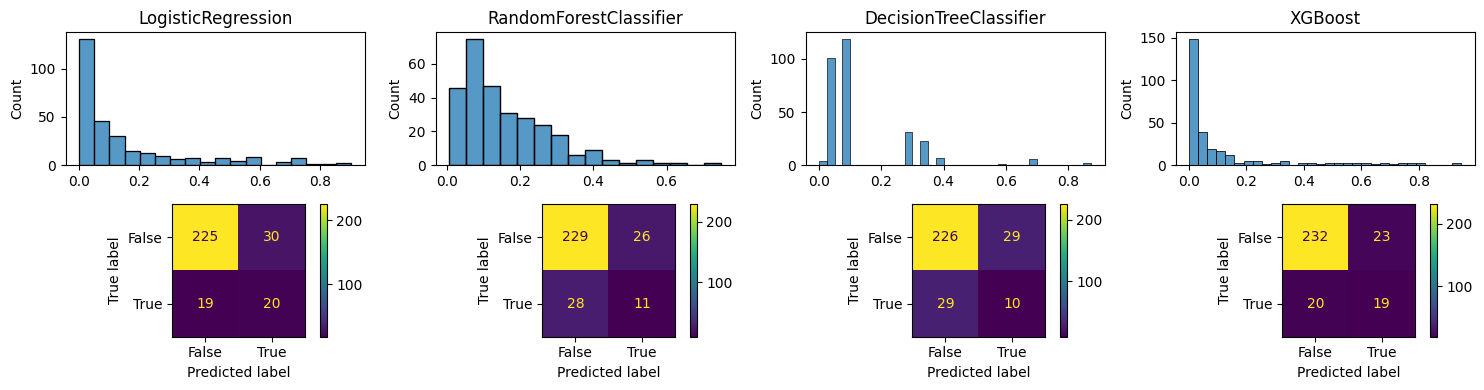

In [679]:
print_results(results_list)
display_results(results_list)

In [680]:
# on essaie de supprimer la feature "niveau_hierarchique_poste" (fortement corrélé à "revenu_mensuel")

X_train.drop(columns=["niveau_hierarchique_poste"], inplace=True)
X_test.drop(columns=["niveau_hierarchique_poste"], inplace=True)

results_list = []
results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams))
results_list.append(entrainement_model("RandomForestClassifier", RandomForestClassifierParams))
results_list.append(entrainement_model("DecisionTreeClassifier", DecisionTreeClassifierParams))
results_list.append(entrainement_model("XGBoost", XGBoostParams))
pass_list.append(results_list)

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

AUC
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.


,model,accuracy,precision,recall,f1,r2,auc,y_proba,y_pred
0,LogisticRegression,0.833333,0.400000,0.512821,0.449438,-0.448567,0.791151,"[0.05718505214507036, 0.00255999765960861, 0.3...","[False, False, True, False, False, True, True,..."
1,RandomForestClassifier,0.819728,0.333333,0.358974,0.345679,-0.566817,0.752841,"[0.11, 0.055, 0.435, 0.095, 0.06, 0.375, 0.125...","[False, False, True, False, False, True, False..."
2,DecisionTreeClassifier,0.802721,0.256410,0.256410,0.256410,-0.714630,0.607793,"[0.2982456140350877, 0.0423728813559322, 0.393...","[False, False, True, False, False, False, Fals..."
3,XGBoost,0.846939,0.428571,0.461538,0.444444,-0.330317,0.785219,"[0.02034307, 0.0141866375, 0.19582923, 0.02361...","[False, False, False, False, False, True, Fals..."


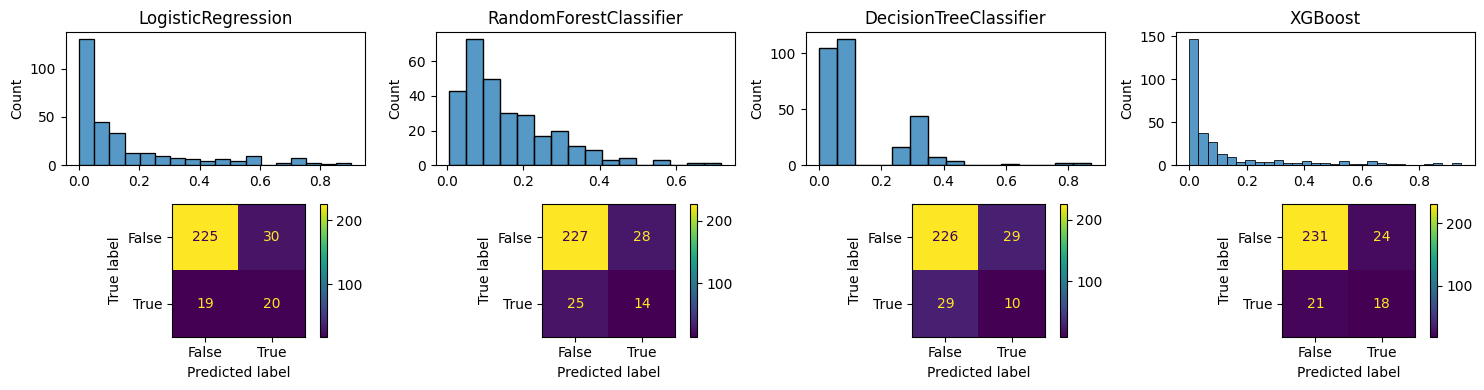

In [681]:
print_results(results_list)
display_results(results_list)

# Vérifie la répartition des données train/test

In [682]:
df["a_quitte_l_entreprise"].value_counts(normalize=True)

a_quitte_l_entreprise
False    0.838776
True     0.161224
Name: proportion, dtype: float64

In [683]:
y_train.value_counts()

a_quitte_l_entreprise
False    978
True     198
Name: count, dtype: int64

In [684]:
y_test.value_counts()

a_quitte_l_entreprise
False    255
True      39
Name: count, dtype: int64

In [685]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[244  11]
 [ 24  15]]


# amélioration du modèle

In [686]:
RandomForestClassifierParams["class_weight"] = "balanced"
XGBoostParams["scale_pos_weight"] = 986 / 190

results_list = []
results_list.append(entrainement_model("LogisticRegression", LogisticRegressionParams))
results_list.append(entrainement_model("RandomForestClassifier", RandomForestClassifierParams))
results_list.append(entrainement_model("DecisionTreeClassifier", DecisionTreeClassifierParams))
results_list.append(entrainement_model("XGBoost", XGBoostParams))
pass_list.append(results_list)

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

AUC
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.


,model,accuracy,precision,recall,f1,r2,auc,y_proba,y_pred
0,LogisticRegression,0.833333,0.400000,0.512821,0.449438,-0.448567,0.791151,"[0.05718505214507036, 0.00255999765960861, 0.3...","[False, False, True, False, False, True, True,..."
1,RandomForestClassifier,0.751701,0.306818,0.692308,0.425197,-1.158069,0.769231,"[0.195, 0.07, 0.53, 0.145, 0.135, 0.53, 0.195,...","[False, False, True, False, False, True, False..."
2,DecisionTreeClassifier,0.802721,0.256410,0.256410,0.256410,-0.714630,0.607793,"[0.2982456140350877, 0.0423728813559322, 0.393...","[False, False, True, False, False, False, Fals..."
3,XGBoost,0.826531,0.400000,0.615385,0.484848,-0.507692,0.795274,"[0.11183757, 0.02277506, 0.5167675, 0.03024532...","[False, False, True, False, False, True, False..."


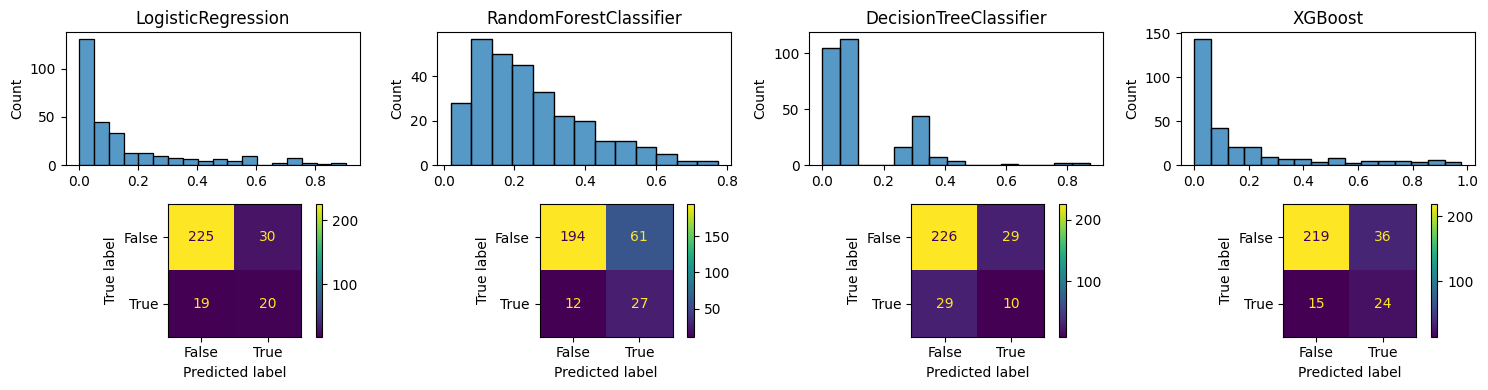

In [687]:
print_results(results_list)
display_results(results_list)

# recherche du meilleur seuil (XGBoost)

R²
   1.0   = (bon modèle)           prédictions exactes 
   0.0   = (mauvais modèle)       prédictions proche de la moyenne simple 
   < 0.0 = (très mauvais modèle)  prédictions pire que la moyenne 

precision / recall
   Precision = fiabilité des alertes
               ex: 0.80 == 80 % sont réellemnt corrects, 20 % sont des erreurs (fausses alertes)
   Recall    = capacité à détecter les vrais cas
               ex: 0.80 == 80 % sont réellemnt trouvé, 20 % sont manqués
   F1-score  = équilibre entre les deux (1: parfais, 0: mauvais)
   Exemple : Precision = 0.80 et Recall = 0.60 -> le modèle trouve 60% des positifs avec une précision de 80%, donc 20% d'erreurs

AUC
   Exemple : AUC = 0.95, le modèle a 95% de chances de donner un score plus élevé à un vrai positif qu’à un vrai négatif.


,model,accuracy,precision,recall,f1,r2,auc,y_proba,y_pred
0,XGBoost,0.87415,0.571429,0.205128,0.301887,-0.093816,0.795274,"[0.11183757, 0.02277506, 0.5167675, 0.03024532...","[False, False, False, False, False, False, Fal..."


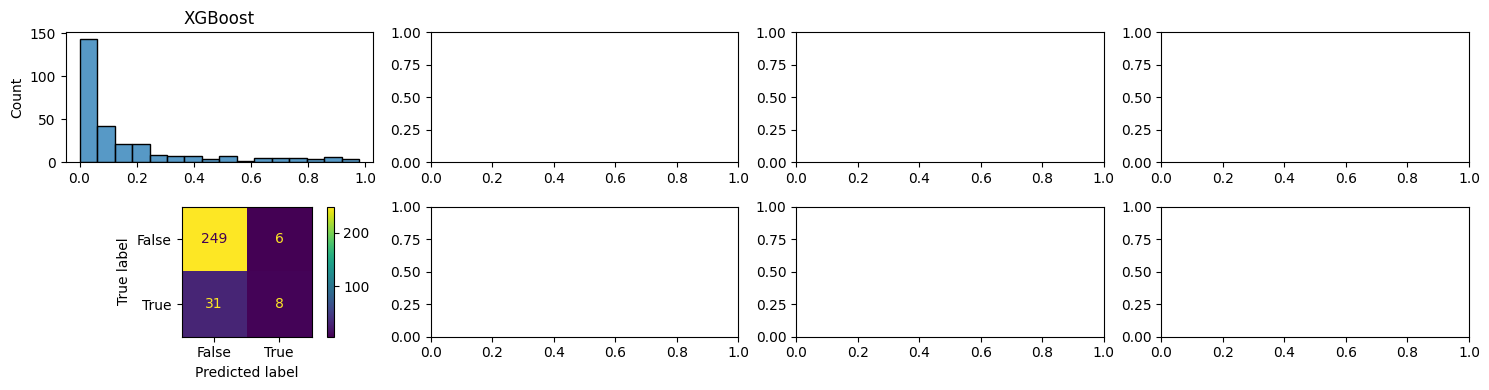

Best threshold: 0.5
Best F1: 0.5384615384615384


In [696]:
best_t, best_f1 = 0, 0

for t in range(1, 9, 1):
    threshold = 0.1 * t
    results_list = []
    results_list.append(entrainement_model("XGBoost", XGBoostParams))
    pass_list.append(results_list)

    f1 = results_list[0]["f1"]

    if f1 > best_f1:
        best_f1 = f1
        best_t = threshold

print_results(results_list)
display_results(results_list)

print("Best threshold:", best_t)
print("Best F1:", best_f1)

threshold = best_t

In [689]:
# optimisation des hyperparamètres

# Affiche un graphique de l'évolution du F1-score

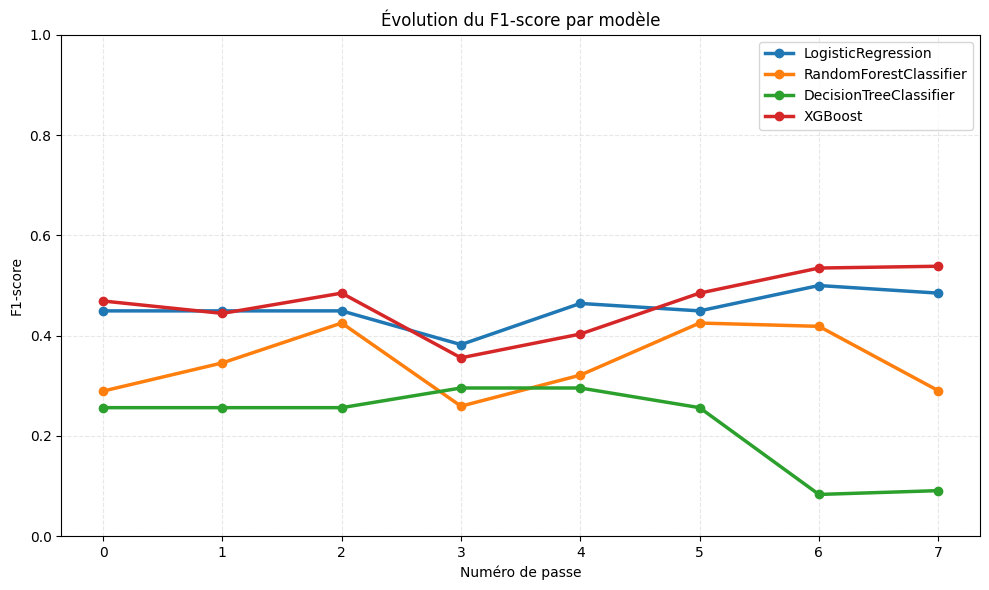

In [690]:
import matplotlib.pyplot as plt
import numpy as np

# noms des modèles (pris sur la première passe)
models = [r["model"] for r in pass_list[0]]

# construction matrice : lignes = passes, colonnes = modèles
data = np.empty((len(pass_list), len(models)))

j = 0
for results_list in pass_list:
    i = 0
    for results in results_list:
        data[j, i] = results["f1"]
        i += 1
    j += 1


# PLOT
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(pass_list))  # numéro de passe

i = 0
for model in models:

    f1_scores = data[:, i]

    ax.plot(
        x,
        f1_scores,
        marker='o',
        linewidth=2.5,
        label=model
    )

    i += 1

ax.set_ylim(0, 1)
ax.set_title("Évolution du F1-score par modèle")
ax.set_xlabel("Numéro de passe")
ax.set_ylabel("F1-score")
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# Prédictions sur de nouvelles données

# Export

In [691]:
df.to_parquet("model.parquet")